In [1]:
!pip install pandas seaborn --quiet

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
data = pd.read_csv("./dados_de_persistencia/roteador/data.csv")

In [4]:
data.head()

,flow_id,time_sec,total_packages,total_bytes,bps,pps
0,server-mariadb,296.69,1085,240033,809.03,3.66
1,client-mariadb,296.69,1085,122047,411.36,3.66
2,NaN,104.61,1000,174098,1664.19,9.56
3,server-telnet,288.72,272,20777,71.96,0.94
4,client-telnet,288.72,338,24081,83.41,1.17


/tmp/ipykernel_107582/3964441026.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='flow_id', y='bps', palette='tab10')


Text(0, 0.5, 'BPS')

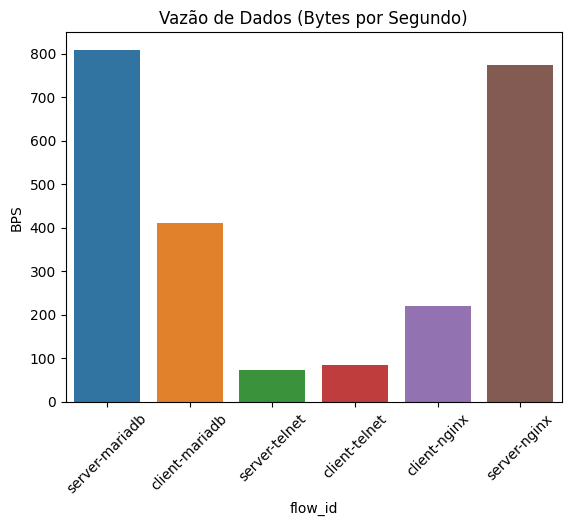

In [5]:
# --- GRÁFICO 1: Vazão por Serviço (BPS) ---
sns.barplot(data=data, x='flow_id', y='bps', palette='tab10')
plt.title('Vazão de Dados (Bytes por Segundo)')
plt.xticks(rotation=45)
plt.ylabel('BPS')

/tmp/ipykernel_107582/3351346017.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='flow_id', y='pps', palette='tab10')


Text(0, 0.5, 'PPS')

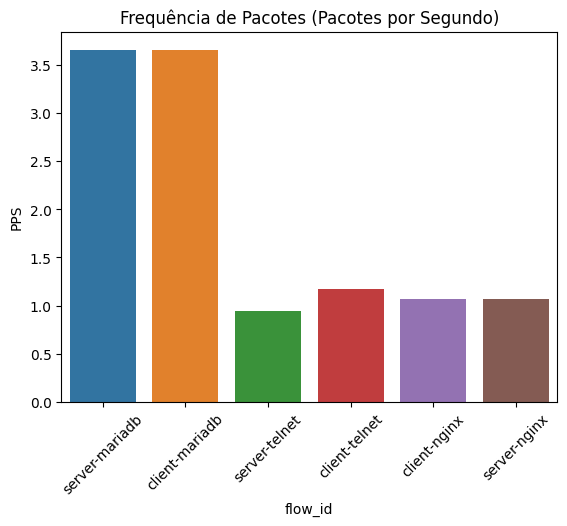

In [6]:
sns.barplot(data=data, x='flow_id', y='pps', palette='tab10')
plt.title('Frequência de Pacotes (Pacotes por Segundo)')
plt.xticks(rotation=45)
plt.ylabel('PPS')

In [16]:
data

,flow_id,time_sec,total_packages,total_bytes,bps,pps
0,server-mariadb,296.69,1085,240033,809.03,3.66
1,client-mariadb,296.69,1085,122047,411.36,3.66
2,NaN,104.61,1000,174098,1664.19,9.56
3,server-telnet,288.72,272,20777,71.96,0.94
4,client-telnet,288.72,338,24081,83.41,1.17
5,client-nginx,279.12,300,61500,220.34,1.07
6,server-nginx,279.12,300,216000,773.87,1.07


/tmp/ipykernel_107582/1362393301.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Direção'] = data['flow_id'].apply(lambda x: 'Server' if 'server' in x else 'Client')
/tmp/ipykernel_107582/1362393301.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Serviço'] = data['flow_id'].apply(lambda x: x.split('-')[1])
/tmp/ipykernel_107582/1362393301.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inste

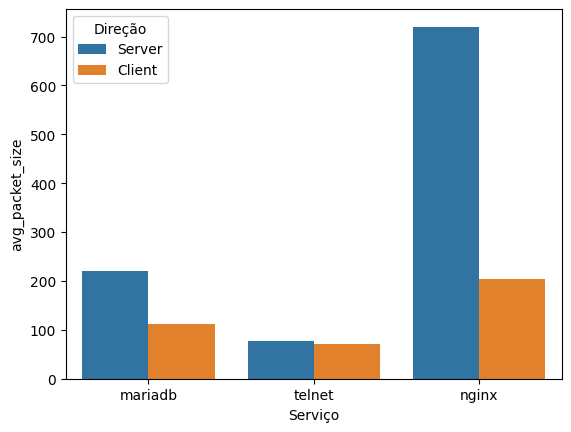

In [17]:
# Criar colunas extras para facilitar a plotagem
data = data.dropna()
data['Direção'] = data['flow_id'].apply(lambda x: 'Server' if 'server' in x else 'Client')
data['Serviço'] = data['flow_id'].apply(lambda x: x.split('-')[1])
data['avg_packet_size'] = data['total_bytes'] / data['total_packages']
# Usando Barplot para comparar o tamanho médio
ax = sns.barplot(data=data, x='Serviço', y='avg_packet_size', hue='Direção', palette='tab10')

Text(0.5, 1.0, 'Relação: Volume de Pacotes vs Volume de Bytes')

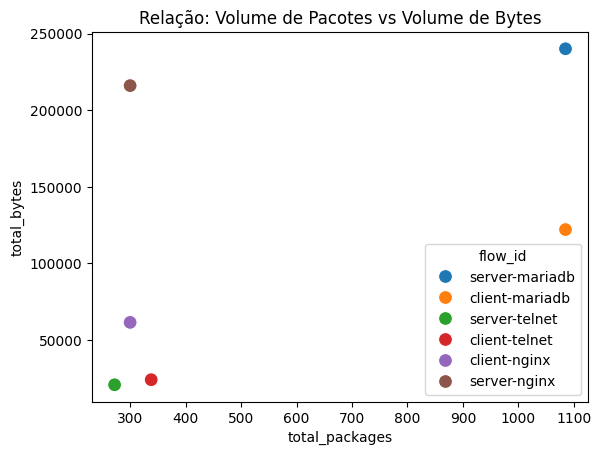

In [18]:
sns.scatterplot(data=data, x='total_packages', y='total_bytes', hue='flow_id', s=100, palette='tab10')
plt.title('Relação: Volume de Pacotes vs Volume de Bytes')

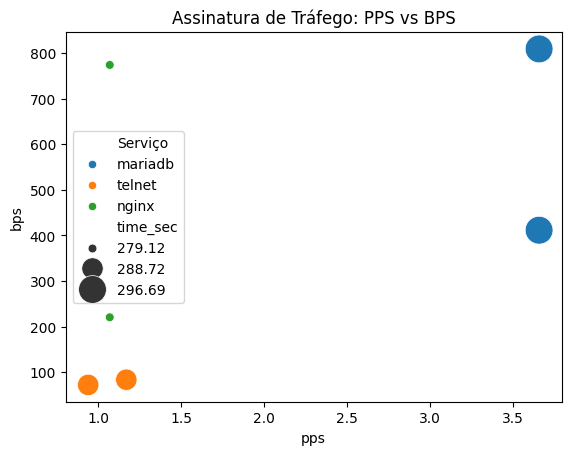

In [19]:
sns.scatterplot(data=data, x='pps', y='bps', hue='Serviço', size='time_sec', sizes=(40, 400))
plt.title("Assinatura de Tráfego: PPS vs BPS")
plt.show()